# Urban Traffic Analysis & ML-Based Prediction System

## Objective
This project analyzes Bangalore traffic data using Machine Learning techniques including regression, dimensionality reduction, classification, and ensemble learning.

## Techniques Used
- Exploratory Data Analysis (EDA)
- Regression Analysis
- PCA & MDS
- LDA & Logistic Regression
- SVM with Kernel Trick
- MLP Neural Network
- Random Forest, AdaBoost, Gradient Boosting

In [83]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

import statsmodels.api as sm

In [84]:
df = pd.read_csv("/content/Blr_Traffic Dataset.csv")

df.head()

,Date,Area Name,Road/Intersection Name,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Weather Conditions,Roadwork and Construction Activity
0,01-01-2022,Indiranagar,100 Feet Road,50590,50.230299,1.500000,100.000000,100.000000,0,151.180,70.632330,84.044600,85.403629,111,Clear,No
1,01-01-2022,Indiranagar,CMH Road,30825,29.377125,1.500000,100.000000,100.000000,1,111.650,41.924899,91.407038,59.983689,100,Clear,No
2,01-01-2022,Whitefield,Marathahalli Bridge,7399,54.474398,1.039069,28.347994,36.396525,0,64.798,44.662384,61.375541,95.466020,189,Clear,No
3,01-01-2022,Koramangala,Sony World Junction,60874,43.817610,1.500000,100.000000,100.000000,1,171.748,32.773123,75.547092,63.567452,111,Clear,No
4,01-01-2022,Koramangala,Sarjapur Road,57292,41.116763,1.500000,100.000000,100.000000,3,164.584,35.092601,64.634762,93.155171,104,Clear,No


**Basic Data Understanding**

In [85]:
df.shape

(8936, 16)

In [86]:
df.columns

Index(['Date', 'Area Name', 'Road/Intersection Name', 'Traffic Volume',
       'Average Speed', 'Travel Time Index', 'Congestion Level',
       'Road Capacity Utilization', 'Incident Reports', 'Environmental Impact',
       'Public Transport Usage', 'Traffic Signal Compliance', 'Parking Usage',
       'Pedestrian and Cyclist Count', 'Weather Conditions',
       'Roadwork and Construction Activity'],
      dtype='object')

In [87]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8936 entries, 0 to 8935
Data columns (total 16 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Date                                8936 non-null   object 
 1   Area Name                           8936 non-null   object 
 2   Road/Intersection Name              8936 non-null   object 
 3   Traffic Volume                      8936 non-null   int64  
 4   Average Speed                       8936 non-null   float64
 5   Travel Time Index                   8936 non-null   float64
 6   Congestion Level                    8936 non-null   float64
 7   Road Capacity Utilization           8936 non-null   float64
 8   Incident Reports                    8936 non-null   int64  
 9   Environmental Impact                8936 non-null   float64
 10  Public Transport Usage              8936 non-null   float64
 11  Traffic Signal Compliance           8936 no

In [88]:
df.describe()

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count
count,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000,8936.000000
mean,29236.048120,39.447427,1.375554,80.818041,92.029215,1.570389,108.472096,45.086651,79.950243,75.155597,114.533348
std,13001.808801,10.707244,0.165319,23.533182,16.583341,1.420047,26.003618,20.208460,11.585006,14.409394,36.812573
min,4233.000000,20.000000,1.000039,5.160279,18.739771,0.000000,58.466000,10.006853,60.003933,50.020411,66.000000
25%,19413.000000,31.775825,1.242459,64.292905,97.354990,0.000000,88.826000,27.341191,69.828270,62.545895,94.000000
50%,27600.000000,39.199368,1.500000,92.389018,100.000000,1.000000,105.200000,45.170684,79.992773,75.317610,102.000000
75%,38058.500000,46.644517,1.500000,100.000000,100.000000,2.000000,126.117000,62.426485,89.957358,87.518589,111.000000
max,72039.000000,89.790843,1.500000,100.000000,100.000000,10.000000,194.078000,79.979744,99.993652,99.995049,243.000000


In [89]:
df["Area Name"].unique()

array(['Indiranagar', 'Whitefield', 'Koramangala', 'M.G. Road',
       'Jayanagar', 'Hebbal', 'Yeshwanthpur', 'Electronic City'],
      dtype=object)

**Data Cleaning**

In [90]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [91]:
df.isnull().sum()

,0
Date,0
Area Name,0
Road/Intersection Name,0
Traffic Volume,0
Average Speed,0
Travel Time Index,0
Congestion Level,0
Road Capacity Utilization,0
Incident Reports,0
Environmental Impact,0


In [92]:
df.duplicated().sum()

np.int64(0)

In [93]:
df = df.drop_duplicates()

**Feature Engineering**

In [94]:
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day
df["Day_of_week"] = df["Date"].dt.dayofweek

In [95]:
le = LabelEncoder()

df["Area_encoded"] = le.fit_transform(df["Area Name"])
df["Weather_encoded"] = le.fit_transform(df["Weather Conditions"])
df["Roadwork_encoded"] = le.fit_transform(df["Roadwork and Construction Activity"])

**Exploratory Data Analysis**

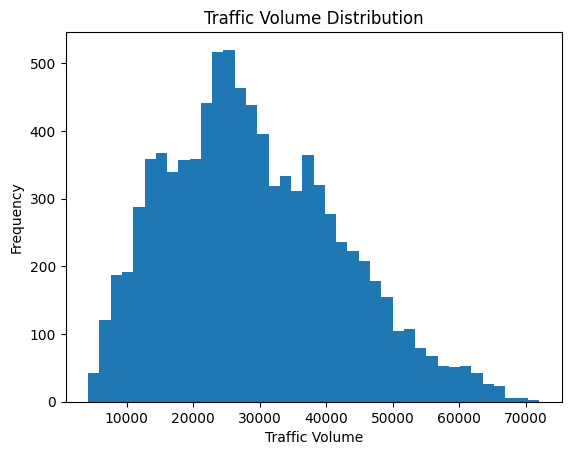

In [96]:
plt.figure()
plt.hist(df["Traffic Volume"], bins=40)
plt.title("Traffic Volume Distribution")
plt.xlabel("Traffic Volume")
plt.ylabel("Frequency")
plt.show()

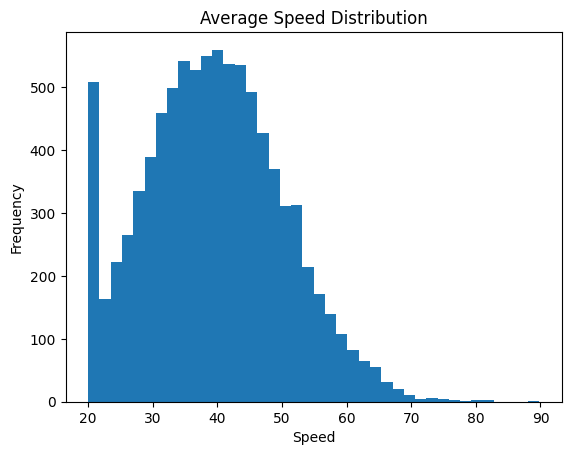

In [97]:
plt.figure()
plt.hist(df["Average Speed"], bins=40)
plt.title("Average Speed Distribution")
plt.xlabel("Speed")
plt.ylabel("Frequency")
plt.show()

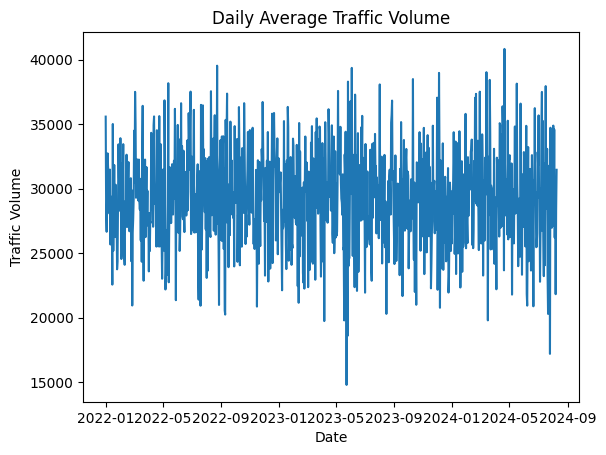

In [98]:
daily = df.groupby("Date")["Traffic Volume"].mean()

plt.figure()
plt.plot(daily.index, daily.values)
plt.title("Daily Average Traffic Volume")
plt.xlabel("Date")
plt.ylabel("Traffic Volume")
plt.show()

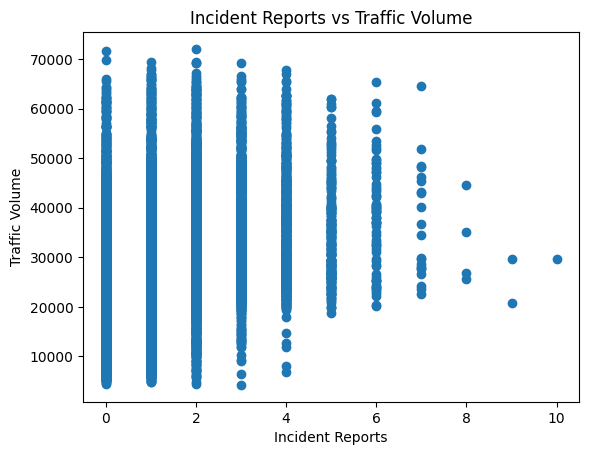

In [99]:
plt.figure()
plt.scatter(df["Incident Reports"], df["Traffic Volume"])
plt.title("Incident Reports vs Traffic Volume")
plt.xlabel("Incident Reports")
plt.ylabel("Traffic Volume")
plt.show()

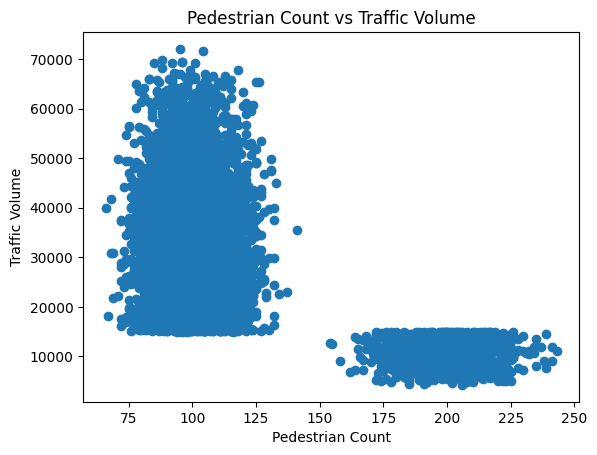

In [100]:
plt.figure()
plt.scatter(df["Pedestrian and Cyclist Count"], df["Traffic Volume"])
plt.title("Pedestrian Count vs Traffic Volume")
plt.xlabel("Pedestrian Count")
plt.ylabel("Traffic Volume")
plt.show()

## EDA Insights

- Traffic volume shows significant variation across different regions of Bangalore.
- Incident reports demonstrate a moderate positive relationship with traffic intensity.
- Higher pedestrian activity appears associated with lower vehicular traffic in several zones.
- Temporal traffic patterns indicate variability across different dates and areas.

**Correlation Analysis**

In [101]:
numeric_cols = df.select_dtypes(include=np.number)

corr = numeric_cols.corr()

corr

,Traffic Volume,Average Speed,Travel Time Index,Congestion Level,Road Capacity Utilization,Incident Reports,Environmental Impact,Public Transport Usage,Traffic Signal Compliance,Parking Usage,Pedestrian and Cyclist Count,Year,Month,Day,Day_of_week,Area_encoded,Weather_encoded,Roadwork_encoded
Traffic Volume,1.000000,-0.341138,0.697514,0.837218,0.652898,0.338766,1.000000,-0.001160,0.005035,-0.025828,-0.554718,-0.008426,0.001157,0.001982,-0.009595,0.011084,0.012947,0.009631
Average Speed,-0.341138,1.000000,-0.376170,-0.360250,-0.249886,-0.158863,-0.341138,0.024437,0.000644,0.000161,0.209209,-0.001421,0.005642,-0.006292,0.004018,0.010845,-0.002574,-0.014786
Travel Time Index,0.697514,-0.376170,1.000000,0.751573,0.507774,0.322942,0.697514,-0.002011,-0.001240,-0.022570,-0.422007,-0.000721,-0.005878,0.001260,-0.005070,-0.007085,0.008794,0.000738
Congestion Level,0.837218,-0.360250,0.751573,1.000000,0.865025,0.418284,0.837218,-0.002783,0.001810,-0.025815,-0.738787,-0.003659,0.008717,-0.004335,-0.006969,-0.016317,0.005251,-0.000533
Road Capacity Utilization,0.652898,-0.249886,0.507774,0.865025,1.000000,0.349976,0.652898,0.000443,0.017135,-0.030358,-0.868422,-0.011230,0.018368,-0.007227,-0.009019,-0.011897,0.001089,-0.012179
Incident Reports,0.338766,-0.158863,0.322942,0.418284,0.349976,1.000000,0.338766,-0.003811,-0.003002,-0.016150,-0.289087,-0.006761,-0.008760,-0.008867,-0.007451,-0.001604,0.003492,-0.011120
Environmental Impact,1.000000,-0.341138,0.697514,0.837218,0.652898,0.338766,1.000000,-0.001160,0.005035,-0.025828,-0.554718,-0.008426,0.001157,0.001982,-0.009595,0.011084,0.012947,0.009631
Public Transport Usage,-0.001160,0.024437,-0.002011,-0.002783,0.000443,-0.003811,-0.001160,1.000000,-0.012765,0.017501,0.002481,-0.005920,-0.002891,-0.005035,-0.007319,0.012580,-0.007357,0.008189
Traffic Signal Compliance,0.005035,0.000644,-0.001240,0.001810,0.017135,-0.003002,0.005035,-0.012765,1.000000,0.010235,-0.009513,0.022855,0.008178,-0.007951,-0.011599,-0.000780,0.005366,0.005374
Parking Usage,-0.025828,0.000161,-0.022570,-0.025815,-0.030358,-0.016150,-0.025828,0.017501,0.010235,1.000000,0.031148,-0.015996,0.000463,0.014231,0.022460,-0.021800,-0.013852,0.000402


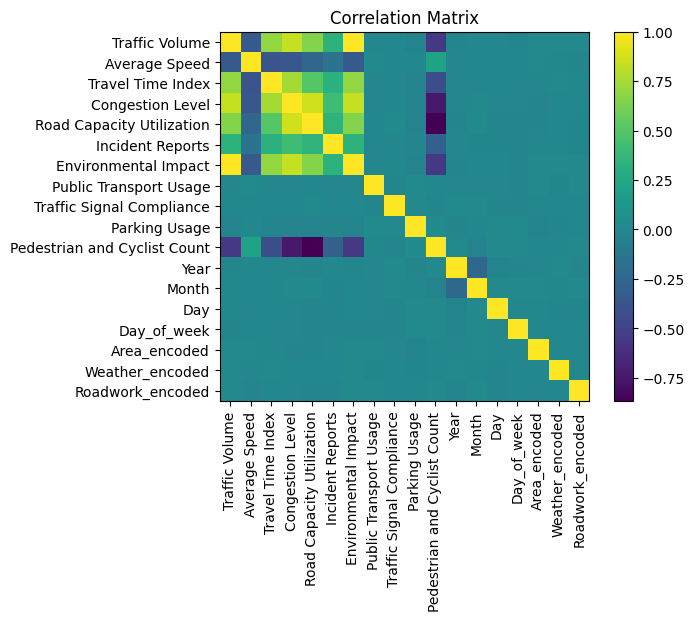

In [102]:
plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Matrix")
plt.show()

**Feature Selection & Regression Preparation**

## Predictor Variable Selection

The selected features represent operational and contextual traffic indicators expected to influence traffic volume. Features with potential leakage or direct derivation from traffic volume were excluded to maintain model reliability and avoid artificially inflated performance.

In [103]:
y = df["Traffic Volume"]

X = df[[
"Average Speed",
"Travel Time Index",
"Incident Reports",
"Pedestrian and Cyclist Count",
"Area_encoded",
"Weather_encoded",
"Roadwork_encoded",
]]

**Train Test Split**

In [104]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

**Feature Scaling**

In [105]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Linear Regression**

In [106]:
model = LinearRegression()

model.fit(X_train, y_train)

pred = model.predict(X_test)

**Model Evaluation**

In [107]:
print("R2 Score:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.5722068840430368
MAE: 6552.805225271271
RMSE: 8472.514620330898


**Ridge Regression**

In [108]:
ridge = Ridge(alpha=1)

ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)

print("R2:", r2_score(y_test, pred_ridge))

R2: 0.5722076049750539


**Lasso Regression**

In [109]:
lasso = Lasso(alpha=0.1)

lasso.fit(X_train, y_train)

pred_lasso = lasso.predict(X_test)

print("R2:", r2_score(y_test, pred_lasso))

R2: 0.5722070891432431


**Statistical Regression**

In [110]:
X_sm = sm.add_constant(X)

model_sm = sm.OLS(y, X_sm).fit()

print(model_sm.summary())

                            OLS Regression Results                            
Dep. Variable:         Traffic Volume   R-squared:                       0.579
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     1752.
Date:                Thu, 07 May 2026   Prob (F-statistic):               0.00
Time:                        08:25:44   Log-Likelihood:                -93466.
No. Observations:                8936   AIC:                         1.869e+05
Df Residuals:                    8928   BIC:                         1.870e+05
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

## Regression Analysis Insights

- Regression models successfully captured relationships between traffic indicators and traffic volume.
- Average Speed and Travel Time Index emerged as important predictive factors.
- Regularization methods such as Ridge and Lasso improved model stability by reducing overfitting.

**Residual Diagnostics**

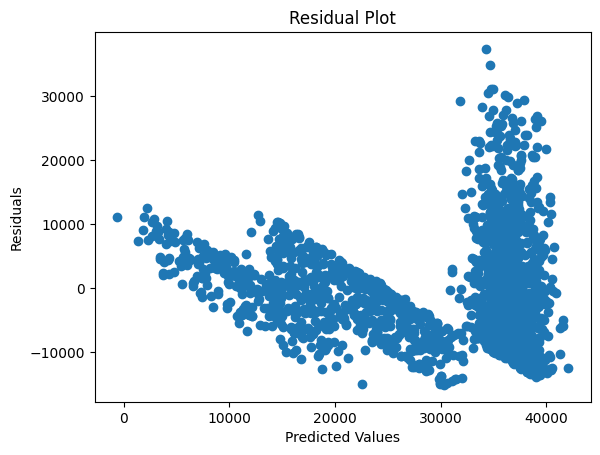

In [111]:
residuals = y_test - pred

plt.figure()
plt.scatter(pred, residuals)
plt.title("Residual Plot")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

**Prediction vs Actual**

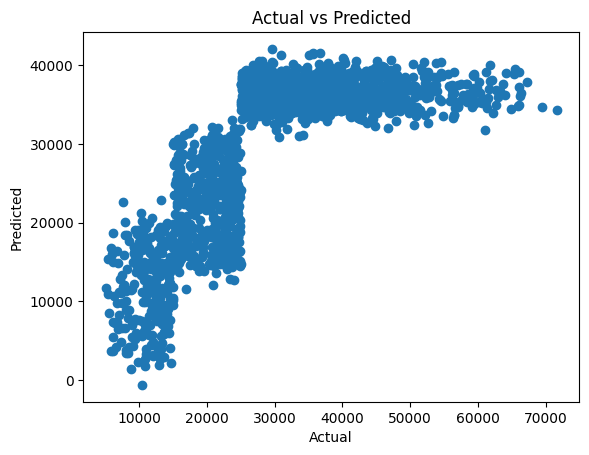

In [112]:
plt.figure()
plt.scatter(y_test, pred)
plt.title("Actual vs Predicted")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

**Data Preprocessing for Modeling**

In [113]:
# Select numerical features
features = [
    "Average Speed",
    "Travel Time Index",
    "Incident Reports",
    "Pedestrian and Cyclist Count",
    "Public Transport Usage",
    "Parking Usage"
]

X = df[features]
y = df["Traffic Volume"]

In [114]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Data Reduction using PCA**

In [115]:
from sklearn.decomposition import PCA

In [116]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.31803397 0.16935723 0.16448876 0.14290148 0.11807568 0.08714288]


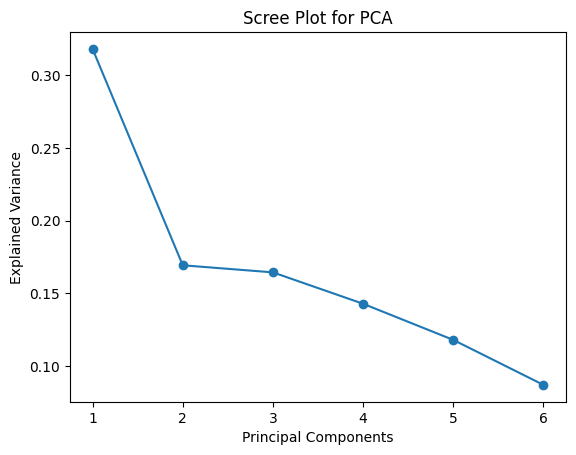

In [117]:
plt.figure()
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot for PCA")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.show()

In [118]:
pca = PCA(n_components=2)

X_pca_2 = pca.fit_transform(X_scaled)

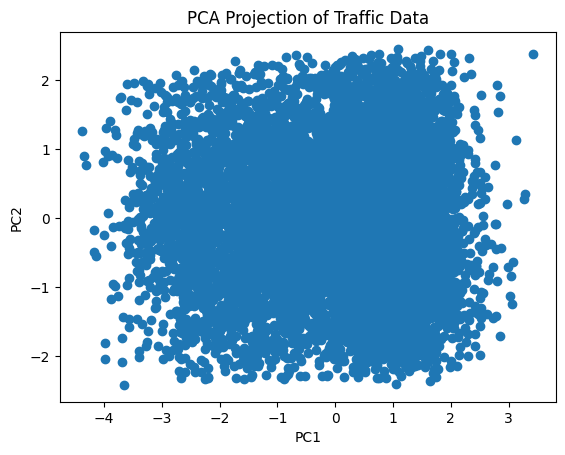

In [119]:
plt.figure()
plt.scatter(X_pca_2[:,0], X_pca_2[:,1])
plt.title("PCA Projection of Traffic Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

## PCA Insights

- Principal Component Analysis reduced feature dimensionality while preserving major variance in the dataset.
- The first few principal components captured a significant portion of traffic-related variability.
- PCA helped simplify the feature space for downstream analysis.

**Data Reduction using Multi-Dimensional Scaling**

In [120]:
from sklearn.manifold import MDS

In [121]:
sample_df = df.sample(n=1000, random_state=42)

X_sample = sample_df[features]

scaler = StandardScaler()
X_sample_scaled = scaler.fit_transform(X_sample)

mds = MDS(
    n_components=2,
    random_state=42,
    max_iter=100,
    n_init=1
)

X_mds = mds.fit_transform(X_sample_scaled)

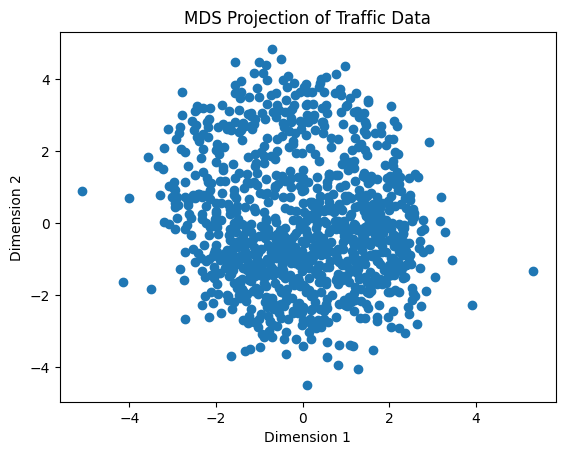

In [122]:
plt.figure()

plt.scatter(X_mds[:,0], X_mds[:,1])

plt.title("MDS Projection of Traffic Data")

plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.show()

**Linear Discrimination (LDA)**

In [123]:
df["Traffic_Class"] = pd.qcut(df["Traffic Volume"], q=3, labels=["Low","Medium","High"])

In [124]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_class = le.fit_transform(df["Traffic_Class"])

In [125]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [126]:
lda = LinearDiscriminantAnalysis()
X_lda = lda.fit_transform(X_scaled, y_class)

In [127]:
print(X_lda.shape)
print(y_class.shape)

(8936, 2)
(8936,)


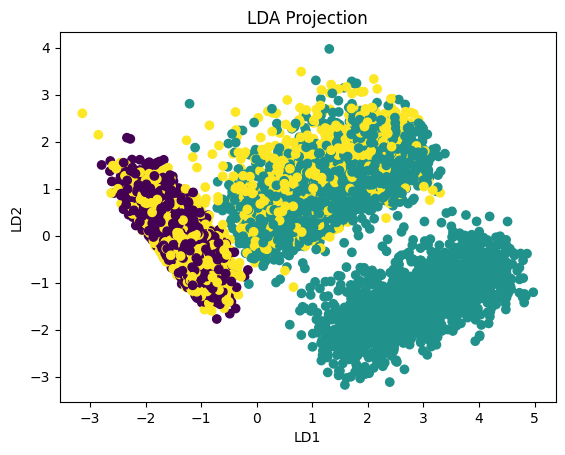

In [128]:
plt.figure()

plt.scatter(
    X_lda[:,0],   # first component
    X_lda[:,1],   # second component
    c=y_class
)

plt.title("LDA Projection")
plt.xlabel("LD1")
plt.ylabel("LD2")

plt.show()

**Logistic Discrimination**

In [129]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_class,
    test_size=0.2,
    random_state=42
)

In [131]:
log_model = LogisticRegression()

log_model.fit(X_train, y_train)

LogisticRegression()

In [132]:
y_pred = log_model.predict(X_test)

In [133]:
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [134]:
print(confusion_matrix(y_test, y_pred))

[[621   0   0]
 [  0 489  78]
 [452  87  61]]


In [135]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      1.00      0.73       621
           1       0.85      0.86      0.86       567
           2       0.44      0.10      0.17       600

    accuracy                           0.65      1788
   macro avg       0.62      0.65      0.58      1788
weighted avg       0.62      0.65      0.58      1788



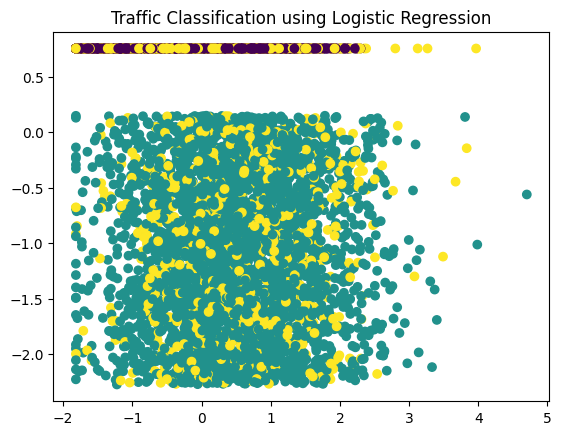

In [136]:
plt.figure()
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_class)
plt.title("Traffic Classification using Logistic Regression")
plt.show()

**Support Vector Machine with Kernel Trick**

In [137]:
df["Traffic_Class"] = pd.qcut(df["Traffic Volume"], q=3, labels=["Low","Medium","High"])
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_class = le.fit_transform(df["Traffic_Class"])

In [138]:
X = df[[
"Average Speed",
"Travel Time Index",
"Incident Reports",
"Pedestrian and Cyclist Count",
"Public Transport Usage",
"Parking Usage"
]]

In [139]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [140]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X_scaled,
y_class,
test_size=0.2,
random_state=42
)

**Linear SVM**

In [141]:
from sklearn.svm import SVC

svm_linear = SVC(kernel="linear")

svm_linear.fit(X_train, y_train)

pred_linear = svm_linear.predict(X_test)

In [142]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_linear))

              precision    recall  f1-score   support

           0       0.58      1.00      0.73       621
           1       0.84      0.91      0.87       567
           2       0.48      0.08      0.14       600

    accuracy                           0.66      1788
   macro avg       0.63      0.66      0.58      1788
weighted avg       0.63      0.66      0.58      1788



**SVM with Kernel Trick (RBF)**

In [143]:
svm_rbf = SVC(kernel="rbf")

svm_rbf.fit(X_train, y_train)

pred_rbf = svm_rbf.predict(X_test)

print(classification_report(y_test, pred_rbf))

              precision    recall  f1-score   support

           0       0.58      0.99      0.73       621
           1       0.83      0.95      0.89       567
           2       0.57      0.08      0.14       600

    accuracy                           0.67      1788
   macro avg       0.66      0.67      0.59      1788
weighted avg       0.66      0.67      0.58      1788



## SVM Insights

- Kernel-based SVM models successfully handled nonlinear relationships within traffic data.
- The RBF kernel improved classification capability compared to linear separation methods.

**Multi-Layer Perceptron (MLP)**

In [144]:
from sklearn.neural_network import MLPClassifier

mlp = MLPClassifier(
hidden_layer_sizes=(50,),
activation="relu",
learning_rate_init=0.001,
max_iter=500
)

mlp.fit(X_train, y_train)

pred_mlp = mlp.predict(X_test)

print(classification_report(y_test, pred_mlp))

              precision    recall  f1-score   support

           0       0.58      0.90      0.71       621
           1       0.84      0.93      0.88       567
           2       0.49      0.17      0.25       600

    accuracy                           0.66      1788
   macro avg       0.64      0.66      0.61      1788
weighted avg       0.63      0.66      0.61      1788



In [145]:
from sklearn.model_selection import GridSearchCV
param_grid = {
"hidden_layer_sizes":[(50,), (100,), (50,50)],
"activation":["relu","tanh"],
"learning_rate_init":[0.001,0.01]
}

In [146]:
grid = GridSearchCV(
MLPClassifier(max_iter=500),
param_grid,
cv=3
)

grid.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


GridSearchCV(cv=3, estimator=MLPClassifier(max_iter=500),
             param_grid={'activation': ['relu', 'tanh'],
                         'hidden_layer_sizes': [(50,), (100,), (50, 50)],
                         'learning_rate_init': [0.001, 0.01]})

In [147]:
print(grid.best_params_)

{'activation': 'relu', 'hidden_layer_sizes': (50,), 'learning_rate_init': 0.001}


**Ensemble Learning Comparison**

**Random Forest**

In [148]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.58      0.71      0.64       621
           1       0.84      0.93      0.88       567
           2       0.45      0.30      0.36       600

    accuracy                           0.64      1788
   macro avg       0.62      0.65      0.63      1788
weighted avg       0.62      0.64      0.62      1788



**AdaBoost**

In [149]:
from sklearn.ensemble import AdaBoostClassifier

ada = AdaBoostClassifier(n_estimators=100)

ada.fit(X_train, y_train)

pred_ada = ada.predict(X_test)

print(classification_report(y_test, pred_ada))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       621
           1       1.00      0.46      0.63       567
           2       0.39      1.00      0.56       600

    accuracy                           0.48      1788
   macro avg       0.46      0.49      0.40      1788
weighted avg       0.45      0.48      0.39      1788



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Gradient Boosting**

In [150]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier()

gb.fit(X_train, y_train)

pred_gb = gb.predict(X_test)

print(classification_report(y_test, pred_gb))

              precision    recall  f1-score   support

           0       0.58      0.91      0.71       621
           1       0.85      0.93      0.89       567
           2       0.49      0.15      0.23       600

    accuracy                           0.66      1788
   macro avg       0.64      0.67      0.61      1788
weighted avg       0.64      0.66      0.61      1788



**Model Comparison Table**

In [151]:
from sklearn.metrics import accuracy_score

models = {
"SVM_RBF":pred_rbf,
"MLP":pred_mlp,
"RandomForest":pred_rf,
"AdaBoost":pred_ada,
"GradientBoost":pred_gb
}

for name,pred in models.items():
    print(name, accuracy_score(y_test,pred))

SVM_RBF 0.6711409395973155
MLP 0.6621923937360179
RandomForest 0.6414988814317674
AdaBoost 0.4809843400447427
GradientBoost 0.6633109619686801


**Visualization of Model Performance**

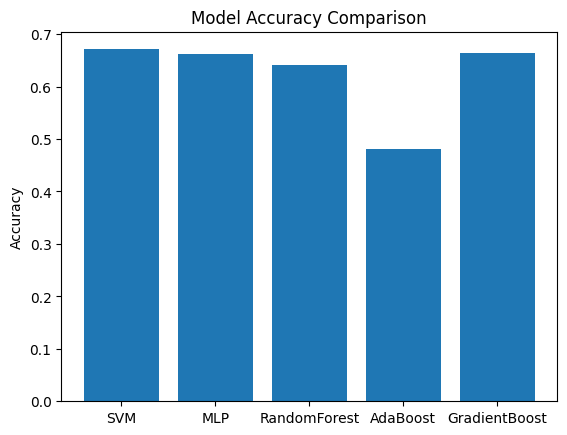

In [152]:
accuracies = [
accuracy_score(y_test,pred_rbf),
accuracy_score(y_test,pred_mlp),
accuracy_score(y_test,pred_rf),
accuracy_score(y_test,pred_ada),
accuracy_score(y_test,pred_gb)
]

names = ["SVM","MLP","RandomForest","AdaBoost","GradientBoost"]

plt.figure()
plt.bar(names,accuracies)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

# Final Conclusion

This project explored Bangalore traffic data using multiple machine learning and statistical techniques. The workflow included exploratory data analysis, regression modeling, dimensionality reduction, classification algorithms, neural networks, and ensemble learning methods.

The analysis demonstrated how machine learning can uncover meaningful traffic patterns and support predictive modeling in urban transportation systems. The project also highlighted the importance of preprocessing, feature selection, and model evaluation in building reliable analytical pipelines.